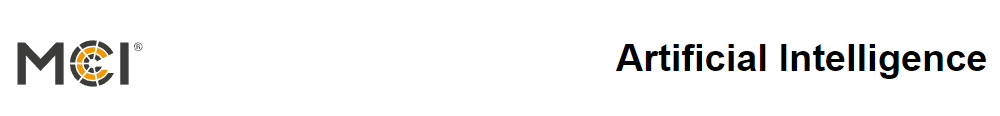

---

# 01 a Clustering with k-Means

Sometimes, Classification is done without a supervised approach. Here we come into the endevor of clustering, which is unsupervised. k-means is one method that is quite common there.

### 1.1. The Problem & Data Aquisition

In darts, the most common game is to play from 501 down to 0 with double out. There are several playing styles. The most common player type is throwing towards the triple 20 field for the majority of the time. But there are also players, that most commonly play on the triple 19 field. In we want to cluster a group of players and their playing style, we could do that quite easily by havin a look on their board distribution (for the first three throws in each leg of a championship game). This is what has been done in an experiment at MCI.

As always, we start with importing the relevant libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

then we import the data from our google drive

In [2]:
championship_data=np.load('../Data/Darts//championship_data.npy')
print(championship_data.shape)
np.random.shuffle(championship_data)

(200, 2)


# 1.2. Processing and Analysis

In this step we have a glance at the data and try to find some meaningful insights.

Here are the relevant dimensions for the dartboard:
* Inner Bull -- 1/2" diameter
* Outer Bull -- 1-1/4" diameter
* Double Ring -- 1/4" Wide -- 4-1/4" radius
* Triple Ring -- 1/4" Wide -- 6-11/16" radius

We use them later for visualization of our data and of the clusters.

The data is shown in the figure below

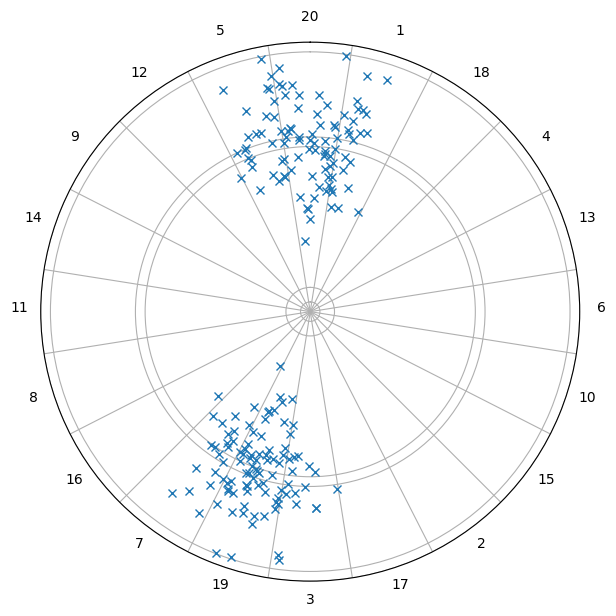

In [3]:
fig, axi = plt.subplots(subplot_kw={'projection': 'polar'})
fig.set_size_inches((7,7))

axi.plot(championship_data[:,1], championship_data[:,0],'x')

# the 5,20,1 etc. field grids
axi.set_thetagrids(list(range(9,369,18)),
         [" "," ", " ", " ", " ", " ", " ", " ", " ", " "
         , " ", " ", " ", " ", " ", " ", " ", " ", " ", " "]
        , verticalalignment='center'
        , horizontalalignment = 'center')
# the proportions radius of inners and outer circle

numbers_score=['20', '5', '12', '9', '14', '11', '8', '16', '7', '19', '3', '17', '2', '15', '10', '6', '13', '4', '18', '1']

for index in range(len(numbers_score)):
    plt.text(index/len(numbers_score)*2*np.pi, 7.5, numbers_score[index], ha='center', rotation=0, wrap=True)

rad = np.linspace(0, 6+11/16+1/4, 21)
azm = np.linspace(0, 2 * np.pi, 21)
axi.set_rgrids([0.1, 1.8])

# radius, r fields outer and inner bullseye
axi.set_rticks([1/4, 5/8, 17/4, 18/4, 6+11/16, 6+11/16+1/4])
axi.set_theta_zero_location("N",offset=0.0)
axi.set_yticklabels([])
radius, theta = np.meshgrid(rad, azm)

It seems, that of 200 throws on the dartboard we have two major aimed fields. The first impression would be the triple 20 and the triple 19 field. Therefore, we can derive that we could use two cluster groups to differentiate between throws aimed for the one or the other field.

# 1.3 Develop the Algorithm for Clustering

As we have learned, kmeans tries to work with centroids for each cluster. It changes the location of the centroid so the sum of the distance to each point in the cluster in minimal. As this is an iterative process we start with the following steps:

* initialize the centroids

in a loop

* (Re-)Assign all points to one cluster
* Calculate the new centroid for the cluster
* Check whether the centroids have changed their location in this iteration

To be able to pull off the steps mentioned above, we need to define some functions that we can call within out loop

In [4]:
# We decide to find two clusters in our data --> Therefore our K = 2
K = 2

# This is our fallback option. If our algorithm takes too many iterations it might be caught in an endless loop.
# So we limit the maximum number of iterations
max_iterations = 20

def update_clusters(centroids, data):
    """ This function computes the updated clusters, precisely the index of the cluster for every data point.
    Parameters:
      centroids: array of K centroids, i.e. for K=1: [(x1,y1), (x2,y2)]
      data: array of N data points, i.e. [(x1,y1), ..., (xN,yN)]
    Returns:
      array of N cluster indices, indicating the cluster per data point, i.e. [i1, i2, i3, ..., iN]
      0 <= cluster_index < K, i.e. for K=2 the result might look like [0,1,0,0,1,1,0,0,0,...,1] of size N.
      This would mean that the first point within data corresponds to cluster0, the second to cluster1, and so on.
    Hints:
      To compute the distance between a centroid and data points use np.linalg.norm().
      Ideally, use a vectorized implementation instead of computing every distance one by one.
      To find the minimum distance np.argmin might be helpful.
      Use the axis argument of numpy functions.
    """
    # First, compute the distance of every point to the K (=2) centroids using np.linalg.norm
    distances = np.array([np.linalg.norm(centroids[k]-data, axis=1) for k in range(K)])

    # Then, set the indices by finding the minimum distance
    cluster_indices = np.argmin(distances, axis=0)

    # Return the result
    return cluster_indices


def compute_means(cluster_indices, data):
    """ This function computes the new centroids (i.e. means) for each cluster. To do so the samples from data with
    the same cluster index
    Parameters:
      cluster_indices: array of N cluster indices, indicating the cluster per data point, i.e. [i1, i2, i3, ..., iN]
      data: array of N data points, i.e. [(x1,y1), ..., (xN,yN)]
    Returns:
      array of K centroids, i.e. for K=3: [(x1,y1), (x2,y2), (x3,y3)]
    Hints:
      Use the axis argument of numpy functions.
    """
    # compute the mean per cluster
    means = np.array([np.mean(data[cluster_indices == k,:], axis=0) for k in range(K)])

    # return the result
    return means


# choose random initial centroids
np.random.seed(seed=4)
idx = np.random.randint(len(championship_data), size=K)
centroids = championship_data[idx,:]

# loop until
# a) convergence (centroids did not change), or
# b) max_iterations reached
for i in range(max_iterations):
    print(centroids)

    # create clusters by assigning points to the closest centroid (update_clusters)
    cluster_indices = update_clusters(centroids, championship_data)

    # save previous centroids to check with new centroids
    previous_centroids = centroids

    # update centroids by computing the mean of the clusters (compute_means)
    centroids = compute_means(cluster_indices, championship_data)

    # check if centroids changed - if not: exit the loop (Hint: use the break statement)
    diff = previous_centroids - centroids
    if not diff.any():
        break

[[4.27178115 0.38458841]
 [4.35797959 2.83315836]]
[[4.43480802 0.01640259]
 [4.31576774 2.80223331]]


We have a result for our two centroids. Visualization is key though, to understand the process better. Therefore, we try to visualize the process. For each iteration, we plot the data, and their current centroid including the assigned datapoint of each cluster.

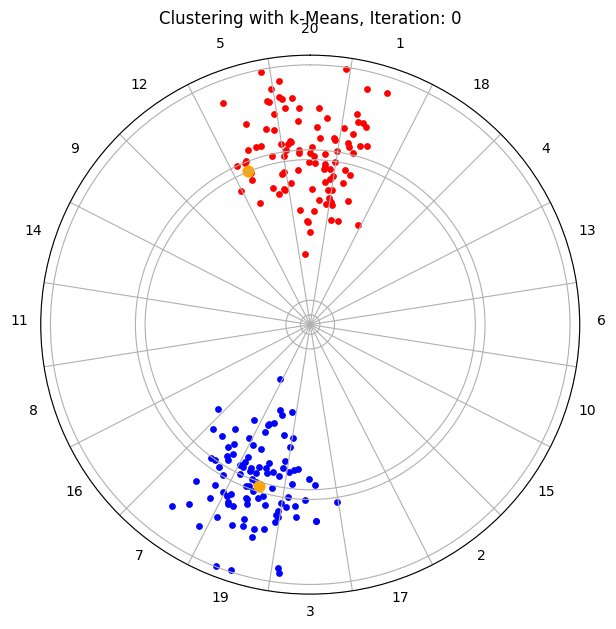

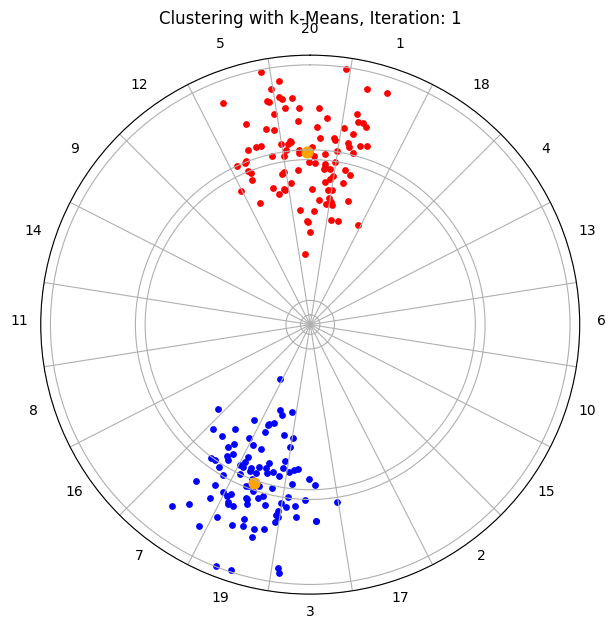

In [5]:
K = 2
max_iterations = 20

def update_clusters(centroids, data):
    distances = np.array([np.linalg.norm(centroids[k]-data, axis=1) for k in range(K)])
    return np.argmin(distances, axis=0)

def compute_means(cluster_indices, data):
    return np.array([np.mean(data[cluster_indices == k,:], axis=0) for k in range(K)])

np.random.seed(seed=4)
idx = np.random.randint(len(championship_data), size=K)
centroids = championship_data[idx,:]

for i in range(max_iterations):
    cluster_indices = update_clusters(centroids, championship_data)


    fig, axi = plt.subplots(subplot_kw={'projection': 'polar'})
    fig.set_size_inches((7,7))

    axi.scatter(championship_data[cluster_indices==0,1], championship_data[cluster_indices==0,0], color="red", s=15, label="Cluster0")
    axi.scatter(championship_data[cluster_indices==1,1], championship_data[cluster_indices==1,0], color="blue", s=15, label="Cluster1")
    axi.scatter(centroids[:,1],centroids[:,0], color="orange", s=60, label="centroids")
    plt.title("Clustering with k-Means, Iteration: "+str(i))

    # the 5,20,1 etc. field grids
    axi.set_thetagrids(list(range(9,369,18)),
         [" "," ", " ", " ", " ", " ", " ", " ", " ", " "
         , " ", " ", " ", " ", " ", " ", " ", " ", " ", " "]
         , verticalalignment='center'
         , horizontalalignment = 'center')
    # the proportions radius of inners and outer circle

    numbers_score=['20', '5', '12', '9', '14', '11', '8', '16', '7', '19', '3', '17', '2', '15', '10', '6', '13', '4', '18', '1']

    for index in range(len(numbers_score)):
        plt.text(index/len(numbers_score)*2*np.pi, 7.5, numbers_score[index], ha='center', rotation=0, wrap=True)

    rad = np.linspace(0, 6+11/16+1/4, 21)
    azm = np.linspace(0, 2 * np.pi, 21)
    axi.set_rgrids([0.1, 1.8])

    # radius, r fields outer and inner bullseye
    axi.set_rticks([1/4, 5/8, 17/4, 18/4, 6+11/16, 6+11/16+1/4])
    axi.set_theta_zero_location("N",offset=0.0)
    axi.set_yticklabels([])
    radius, theta = np.meshgrid(rad, azm)

    previous_centroids = centroids
    centroids = compute_means(cluster_indices, championship_data)
    diff = previous_centroids - centroids
    if not diff.any():
        break

By finding the centroids we also see, that the plyers aimed for the triple 19 field and the triple 20 field.

As the plots with a polar shape are not that easy to grasp (humans are used to think in a classic cartesian coordinate system, not in polar coordinates), we do the same plot once more, but we use a classic cartesian coordinate system.

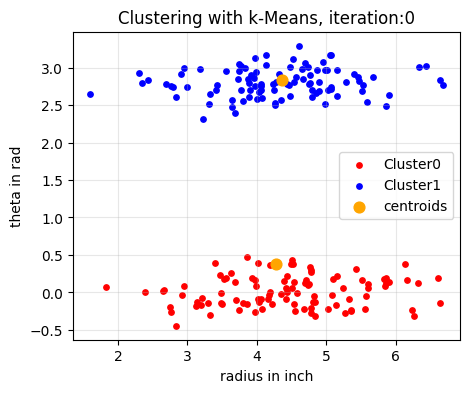

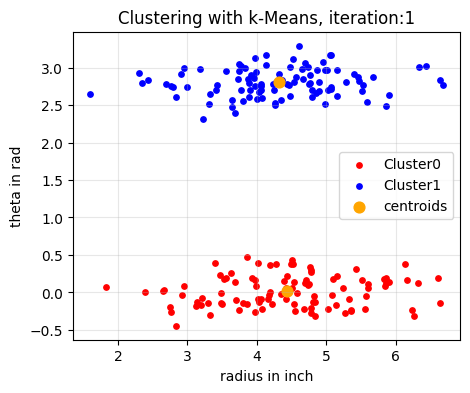

In [6]:
K = 2
max_iterations = 20

def update_clusters(centroids, data):
    distances = np.array([np.linalg.norm(centroids[k]-data, axis=1) for k in range(K)])
    return np.argmin(distances, axis=0)

def compute_means(cluster_indices, data):
    return np.array([np.mean(data[cluster_indices == k,:], axis=0) for k in range(K)])

np.random.seed(seed=4)
idx = np.random.randint(len(championship_data), size=K)
centroids = championship_data[idx,:]

for i in range(max_iterations):
    cluster_indices = update_clusters(centroids, championship_data)


    plt.figure(figsize=(5,4))
    plt.grid(alpha=0.3)
    plt.scatter(championship_data[cluster_indices==0,0], championship_data[cluster_indices==0,1], color="red", s=15, label="Cluster0")
    plt.scatter(championship_data[cluster_indices==1,0], championship_data[cluster_indices==1,1], color="blue", s=15, label="Cluster1")
    plt.scatter(centroids[:,0],centroids[:,1], color="orange", s=60, label="centroids")
    plt.legend()
    plt.title("Clustering with k-Means, iteration:"+str(i))
    plt.xlabel("radius in inch")
    plt.ylabel("theta in rad")
    # plt.savefig("kMeans-result.png", bbox_inches='tight')

    previous_centroids = centroids
    centroids = compute_means(cluster_indices, championship_data)
    diff = previous_centroids - centroids
    if not diff.any():
        break